# Example 3: Wave Spectra and Added Resistance

## Overview

This notebook demonstrates:
1. Creating Pierson-Moskowitz and JONSWAP wave spectra
2. Comparing different wave spectrum models
3. Calculating added resistance in waves using STAwave-2 method
4. Understanding how wave conditions affect ship resistance
5. Analyzing performance across different sea states

## Import Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from ship_model_lib.added_resistance import (
    PiersonMoskowitzSpectrumITTC1978,
    JONSWAPSpectrumITTC1984,
    AddedResistanceByStaWave2,
)
from ship_model_lib.ship_dimensions import ShipDimensionsAddedResistance
from ship_model_lib.operation_profile_structure import Weather
from ship_model_lib.ship_types import WaveSpectrumType

## Part 1: Wave Spectra Comparison

### Sea State Parameters

Wave spectra are characterized by:
- **Significant Wave Height ($H_s$)**: Average height of highest 1/3 of waves
- **Mean Wave Period ($T_1$)**: Average time between wave crests

### Spectrum Models

1. **Pierson-Moskowitz (ITTC 1978)**: Fully developed sea
2. **JONSWAP (ITTC 1984)**: Fetch-limited sea with peakedness parameter $\gamma$
   - $\gamma = 1.0$: Equivalent to Pierson-Moskowitz
   - $\gamma = 3.3$: Standard North Sea conditions
   - $\gamma = 7.0$: Very peaked spectrum

In [2]:
# Define sea state parameters
significant_wave_height_m = 4.0
mean_wave_period_s = 8.0

print(f"Sea State Parameters:")
print(f"  Significant Wave Height (Hs): {significant_wave_height_m} m")
print(f"  Mean Wave Period (T1):        {mean_wave_period_s} s")

Sea State Parameters:
  Significant Wave Height (Hs): 4.0 m
  Mean Wave Period (T1):        8.0 s


### Create Wave Spectra

In [3]:
# Create Pierson-Moskowitz spectrum
spectrum_pm = PiersonMoskowitzSpectrumITTC1978(
    mean_wave_period_s=mean_wave_period_s,
    significant_wave_height_m=significant_wave_height_m,
)

# Create JONSWAP spectra with different gamma values
gamma_values = [1.0, 3.3, 7.0]
spectra_jonswap = []
for gamma in gamma_values:
    spectrum = JONSWAPSpectrumITTC1984(
        significant_wave_height_m=significant_wave_height_m,
        mean_wave_period_s=mean_wave_period_s,
        gamma=gamma,
    )
    spectra_jonswap.append((gamma, spectrum))

print(f"\nCreated spectra:")
print(f"  ✓ Pierson-Moskowitz (ITTC 1978)")
print(f"  ✓ JONSWAP with γ = 1.0 (fully developed sea)")
print(f"  ✓ JONSWAP with γ = 3.3 (North Sea standard)")
print(f"  ✓ JONSWAP with γ = 7.0 (very peaked)")


Created spectra:
  ✓ Pierson-Moskowitz (ITTC 1978)
  ✓ JONSWAP with γ = 1.0 (fully developed sea)
  ✓ JONSWAP with γ = 3.3 (North Sea standard)
  ✓ JONSWAP with γ = 7.0 (very peaked)


### Visualize Wave Spectra

→ Saved 'example_03_wave_spectra.png'


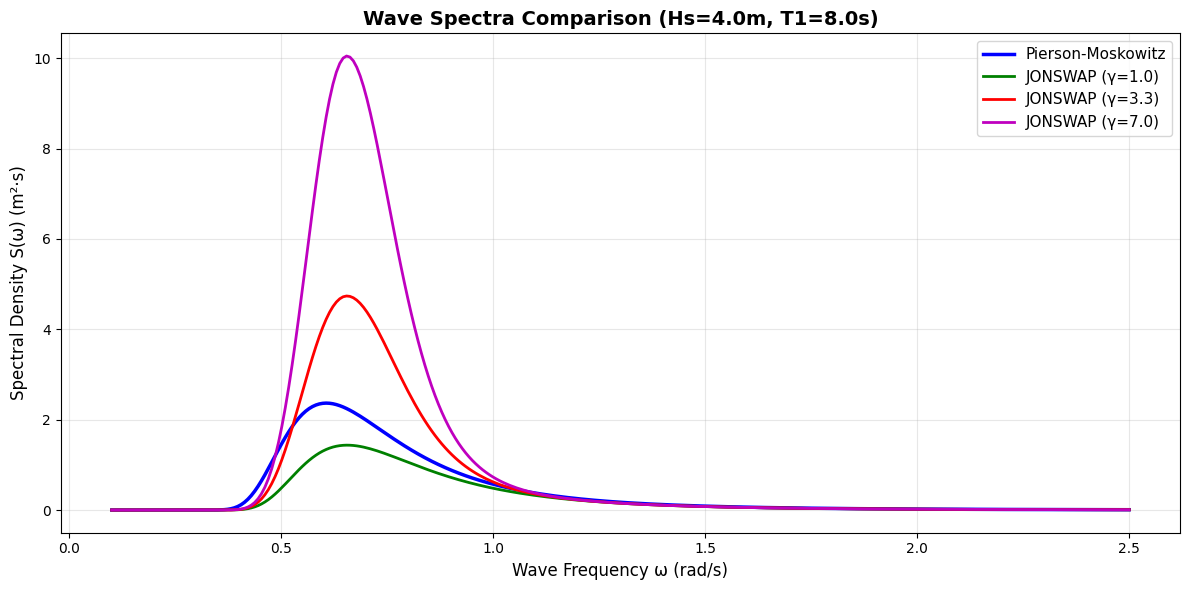

In [4]:
# Calculate spectral densities
omega = np.linspace(0.1, 2.5, 300)
spectrum_density_pm = spectrum_pm.get_spectral_density_omega(omega_rad_per_s=omega)

# Create visualization
plt.figure(figsize=(12, 6))
plt.plot(omega, spectrum_density_pm, 'b-', linewidth=2.5, label='Pierson-Moskowitz')

colors = ['g', 'r', 'm']
for (gamma, spectrum), color in zip(spectra_jonswap, colors):
    spectrum_density = spectrum.get_spectral_density_omega(omega_rad_per_s=omega)
    plt.plot(omega, spectrum_density, f'{color}-', linewidth=2, label=f'JONSWAP (γ={gamma})')

plt.xlabel('Wave Frequency ω (rad/s)', fontsize=12)
plt.ylabel('Spectral Density S(ω) (m²·s)', fontsize=12)
plt.title(f'Wave Spectra Comparison (Hs={significant_wave_height_m}m, T1={mean_wave_period_s}s)',
          fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig('example_03_wave_spectra.png', dpi=150, bbox_inches='tight')
print("→ Saved 'example_03_wave_spectra.png'")
plt.show()

## Part 2: Ship Dimensions and Added Resistance

### Define Ship Characteristics

Example: Medium-sized container ship

In [5]:
# Define ship dimensions
ship_dimension = ShipDimensionsAddedResistance(
    b_beam_m=32.26,
    lpp_length_between_perpendiculars_m=190,
    cb_block_coefficient=0.6,
    ta_draft_aft_m=9.5,
    tf_draft_forward_m=9.5,
    kyy_radius_gyration_in_lateral_direction_non_dim=0.26,
)

print(f"Ship Dimensions:")
print(f"  Length (Lpp):      {ship_dimension.lpp_length_between_perpendiculars_m} m")
print(f"  Beam (B):          {ship_dimension.b_beam_m} m")
print(f"  Draft (T):         {ship_dimension.ta_draft_aft_m} m")
print(f"  Block Coeff (Cb):  {ship_dimension.cb_block_coefficient}")

Ship Dimensions:
  Length (Lpp):      190 m
  Beam (B):          32.26 m
  Draft (T):         9.5 m
  Block Coeff (Cb):  0.6


In [6]:
# Define ship speed
ship_speed_kn = 15.0
ship_speed_ms = ship_speed_kn * 0.514444

print(f"Ship Speed: {ship_speed_kn} knots ({ship_speed_ms:.2f} m/s)")

Ship Speed: 15.0 knots (7.72 m/s)


### Calculate Added Resistance vs Wave Height

The **STAwave-2** method calculates added resistance in irregular waves.

Assumed calm water resistance for reference: 300 kN

In [7]:
wave_heights = np.array([0.5, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0])
added_resistances = []
calm_water_resistance_kn = 300.0

print(f"{'Wave Height (m)':>16} | {'Added Resistance (kN)':>24} | {'% Increase':>12}")
print("-" * 60)

for hs in wave_heights:
    # Create weather with JONSWAP spectrum
    weather = Weather(
        significant_wave_height_m=hs,
        mean_wave_period_s=mean_wave_period_s,
        wave_direction_deg=0.0,
    )
    
    # Calculate added resistance
    added_resistance_model = AddedResistanceByStaWave2(
        ship_dimension=ship_dimension,
        wave_spectrum_type=WaveSpectrumType.JONSWAP_ITTC_1984,
    )
    
    raw_kn = added_resistance_model.get_added_resistance_newton(
        vessel_speed_kn=ship_speed_kn,
        weather=weather,
        heading_deg=0.0,
    ) * 1e-3  # Convert N to kN
    raw_kn = float(np.asarray(raw_kn).squeeze())
    added_resistances.append(raw_kn)
    
    percent_increase = (raw_kn / calm_water_resistance_kn) * 100
    
    print(f"{hs} | {raw_kn:.1f} | {percent_increase:.1f}%")

added_resistances = np.array(added_resistances)

 Wave Height (m) |    Added Resistance (kN) |   % Increase
------------------------------------------------------------
0.5 | 7.6 | 2.5%
1.0 | 30.5 | 10.2%
2.0 | 122.1 | 40.7%
3.0 | 274.7 | 91.6%
4.0 | 488.4 | 162.8%
5.0 | 763.1 | 254.4%
6.0 | 1098.8 | 366.3%


## Part 3: Visualization of Added Resistance

→ Saved 'example_03_added_resistance.png'


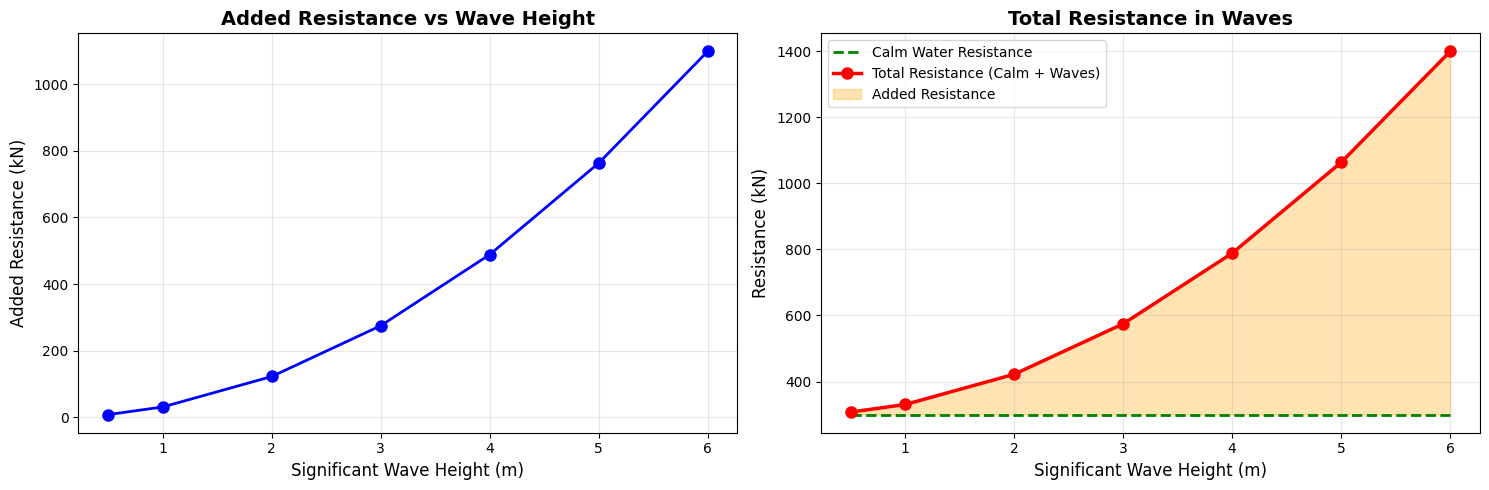

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Added Resistance vs Wave Height
ax1.plot(wave_heights, added_resistances, 'bo-', linewidth=2, markersize=8)
ax1.set_xlabel('Significant Wave Height (m)', fontsize=12)
ax1.set_ylabel('Added Resistance (kN)', fontsize=12)
ax1.set_title('Added Resistance vs Wave Height', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)

# Plot 2: Total Resistance vs Wave Height
total_resistance = calm_water_resistance_kn + added_resistances
ax2.plot(wave_heights, [calm_water_resistance_kn] * len(wave_heights), 
         'g--', linewidth=2, label='Calm Water Resistance')
ax2.plot(wave_heights, total_resistance, 'r-', linewidth=2.5, 
         marker='o', markersize=8, label='Total Resistance (Calm + Waves)')
ax2.fill_between(wave_heights, calm_water_resistance_kn, total_resistance,
                 alpha=0.3, color='orange', label='Added Resistance')
ax2.set_xlabel('Significant Wave Height (m)', fontsize=12)
ax2.set_ylabel('Resistance (kN)', fontsize=12)
ax2.set_title('Total Resistance in Waves', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.legend(fontsize=10)

plt.tight_layout()
plt.savefig('example_03_added_resistance.png', dpi=150, bbox_inches='tight')
print("→ Saved 'example_03_added_resistance.png'")
plt.show()

## Summary

In [9]:
print(f"At Hs = {wave_heights[-1]}m:")
print(f"  - Added Resistance:   {added_resistances[-1]:.2f} kN")
print(f"  - Calm Water:         {calm_water_resistance_kn:.2f} kN")
print(f"  - Total Resistance:   {total_resistance[-1]:.2f} kN")
print(f"  - Increase:           {(added_resistances[-1]/calm_water_resistance_kn)*100:.1f}%")

At Hs = 6.0m:
  - Added Resistance:   1098.82 kN
  - Calm Water:         300.00 kN
  - Total Resistance:   1398.82 kN
  - Increase:           366.3%


## Key Takeaways

1. **Wave Spectra:**
   - Pierson-Moskowitz models fully developed seas
   - JONSWAP allows tuning peakedness with γ parameter
   - Higher γ values create more peaked spectra

2. **Added Resistance:**
   - Increases significantly with wave height
   - Can be 20-40% of calm water resistance in moderate seas
   - Critical for fuel consumption and voyage planning

3. **STAwave-2 Method:**
   - Empirical method based on STA-JIP dataset
   - Accounts for ship geometry and wave characteristics
   - Suitable for preliminary design and performance estimation